# **Context**
Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

# **Objective**
In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

Facilitate the process of visa approvals.
Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.


# **Data Description**
The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.



1.  case_id: ID of each visa application
2.  continent: Information of continent the employee
3.  education_of_employee: Information of education of the employee
4.  has_job_experience: Does the employee has any job experience? Y= Yes; N = No
5. requires_job_training: Does the employee require any job training? Y = Yes; N = No
6. no_of_employees: Number of employees in the employer's company
7. yr_of_estab: Year in which the employer's company was established
8. region_of_employment: Information of foreign worker's intended region of employment in the US.
9. prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.

10. unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly

11. full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position

12. case_status: Flag indicating if the Visa was certified or denied









# **Importing Packages**

In [1]:
#Installing the libraries with specific versions
!pip install pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 xgboost==2.1.4 imbalanced-learn==0.13.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 7.6 MB/s eta 0:00:00


In [2]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

# **Loading and Creating Copy of the data**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
visadetails_data = pd.read_csv("/content/drive/MyDrive/Santhosh-Notebooks/Bagging-Boosting/EasyVisa.csv")
data=visadetails_data.copy()

# **Understanding Dataset provided**

In [5]:
data.shape

(25480, 12)

In [6]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [7]:
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified




*   The dataset contains 25,480 visa application records , that means 25480 rows and 12 columns.
*   Each record represents an employer petition for visa certification.
*  Target variable case_status indicates whether an application is Certified or Denied.
*  Dataset includes employee details (education, experience, training requirement)
* Employer information includes company size, establishment year, and region of employment.

* Wage information is provided along with its unit.
* Employment type indicates full-time or part-time roles.




In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [9]:
data.isnull().sum()


,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [10]:
data.duplicated().sum()

np.int64(0)

*  The dataset contains 25,480 records with 12 columns representing visa applications.
*  All columns have complete data with no missing values, indicating good data quality.
* Dataset includes:

    * Categorical features such as continent, education, experience, region of employment, wage unit, and case status.

    * Numerical features including number of employees, year of establishment, and prevailing wage.
*  Majority of columns are categorical (object type), requiring encoding before model training.

*  Numerical columns will need scaling or transformation where necessary due to skewness and outliers.

*  Memory usage is low, indicating efficient data size suitable for modeling without computational concerns.


In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


In [12]:
data.loc[data['no_of_employees']<0,'no_of_employees'].count()

np.int64(33)


1. Number of Employees
*   Employee count shows strong right skew as mean is much higher than median.
*   Presence of very large companies leads to outliers.
*   Negative employee values exist, which are invalid and require cleaning.

2. Year of Establishment
*  Companies range from very old to recently established firms.
*  Raw establishment year is less meaningful for modeling.
*  Company age will be derived for better interpretation.

3. Prevailing Wage
*  Wage distribution shows large variation across applications.
*  Extremely low and very high wages suggest possible outliers or different wage units.
*  Wage values require normalization based on wage units.









         







## **Final Dataset Summary**

1. The dataset contains 25,480 visa application records, each representing an employer’s request for visa certification.
2. Data includes both employee attributes (education, job experience, training requirement) and employer attributes (company size, establishment year, and employment region).
3. Employee counts vary widely across companies, with extreme values and some invalid negative entries indicating the need for data cleaning.
4. Companies in the dataset range from very old to recently established firms, making it useful to derive company age as a feature.
5. Prevailing wages vary significantly across visa applications, partly due to different wage units and the presence of outliers, requiring normalization.
6. Dataset contains categorical, numerical, and binary features that require preprocessing and encoding before modeling.

***Overall, the dataset is suitable for predictive modeling but requires data cleaning, feature engineering, and preprocessing to improve model performance.***

# **Exploratory Data Analysis**

## **Univariate Analysis for Categorical Variables**

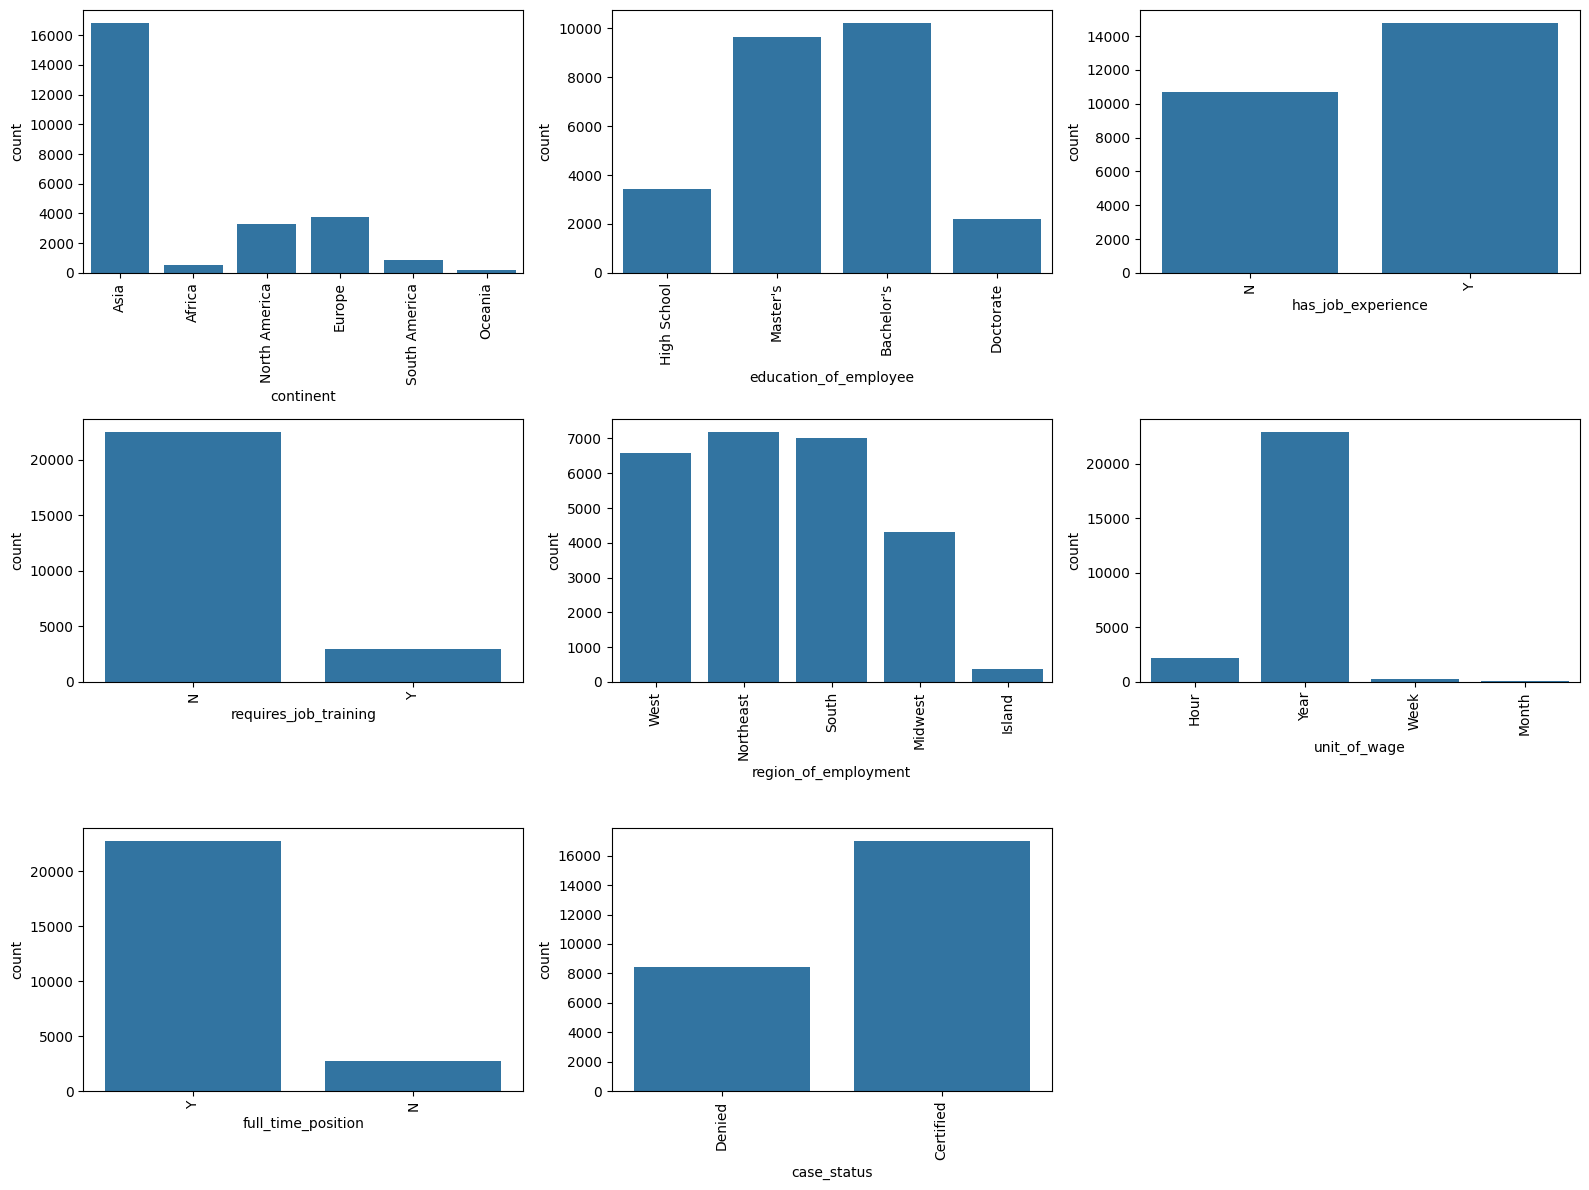

In [13]:
plt.figure(figsize=(16, 12))

# defining the list of numerical features to plot
categorical_features = ['continent','education_of_employee','has_job_experience','requires_job_training','region_of_employment','unit_of_wage','full_time_position','case_status']

# plotting the histogram for each numerical feature
for i, feature in enumerate(categorical_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.countplot(data=data, x=feature)    # plot the histogram
    plt.xticks(rotation=90)    # rotate the x-axis labels for better readability

plt.tight_layout();   # to add spacing between plots

In [14]:
data['continent'].value_counts(normalize=True) * 100


,proportion
continent,
Asia,66.173
Europe,14.647
North America,12.920
South America,3.344
Africa,2.162
Oceania,0.754


**Continent**

* Asia accounts for 66.17% of total visa applications, making it the dominant source region, followed by Europe (14.65%) and North America (12.92%), while applications from other continents form only a small proportion of total cases.

* Africa, South America, and Oceania contribute relatively fewer applications.

In [15]:
data['education_of_employee'].value_counts(normalize=True) * 100

,proportion
education_of_employee,
Bachelor's,40.165
Master's,37.810
High School,13.422
Doctorate,8.603


**Education of Employee**

* Applicants with a Bachelor’s degree constitute 40.17% of total visa applications, followed by Master’s degree holders at 37.81%, indicating that the majority of applicants possess undergraduate or postgraduate qualifications.

* High School graduates account for 13.42%, while Doctorate holders represent the smallest share at 8.60% of applications.



In [16]:
data['has_job_experience'].value_counts(normalize=True) * 100

,proportion
has_job_experience,
Y,58.093
N,41.907


**Job Experience**

* Approximately 58.09% of visa applicants have prior job experience, while 41.91% do not, indicating that a larger share of applications comes from candidates with existing professional experience.

In [17]:
data['requires_job_training'].value_counts(normalize=True) * 100

,proportion
requires_job_training,
N,88.403
Y,11.597


**Job Training**

* Approximately 88.40% of job positions do not require additional training, while only 11.60% require training, indicating that most visa applications are for roles where candidates are expected to be job-ready without further training.

In [18]:


data['region_of_employment'].value_counts(normalize=True) * 100

,proportion
region_of_employment,
Northeast,28.238
South,27.539
West,25.848
Midwest,16.903
Island,1.472


**Region Of Employment**

* Employment demand is highest in the Northeast region, accounting for 28.24% of applications, followed closely by the South (27.54%) and West (25.85%), indicating that most visa-sponsored roles are concentrated in these regions.

*  The Midwest accounts for 16.90%, while the Island region represents only 1.47%, contributing the smallest share of employment applications.

In [19]:


data['unit_of_wage'].value_counts(normalize=True) * 100

,proportion
unit_of_wage,
Year,90.118
Hour,8.465
Week,1.068
Month,0.349


**Unit Of Wage**

* The majority of wages are reported on a yearly basis, accounting for 90.12% of applications, indicating that most job offers specify annual compensation.
* Hourly wages account for 8.47% of cases, while weekly (1.07%) and monthly (0.35%) wage units are rarely used.

In [20]:
data['full_time_position'].value_counts(normalize=True) * 100

,proportion
full_time_position,
Y,89.376
N,10.624


**Full Time Positions**

* Approximately 89.38% of visa applications are for full-time positions, while only 10.62% correspond to part-time roles, indicating that most visa-sponsored employment opportunities are full-time in nature.

In [21]:
data['case_status'].value_counts(normalize=True) * 100

,proportion
case_status,
Certified,66.790
Denied,33.210


**Case Status**

Approximately 66.79% of visa applications are certified, while 33.21% are denied, indicating that approvals form the majority of cases. This also suggests a moderate class imbalance that should be considered during model training.

## **Univariate Analysis for Numerical  Variables**

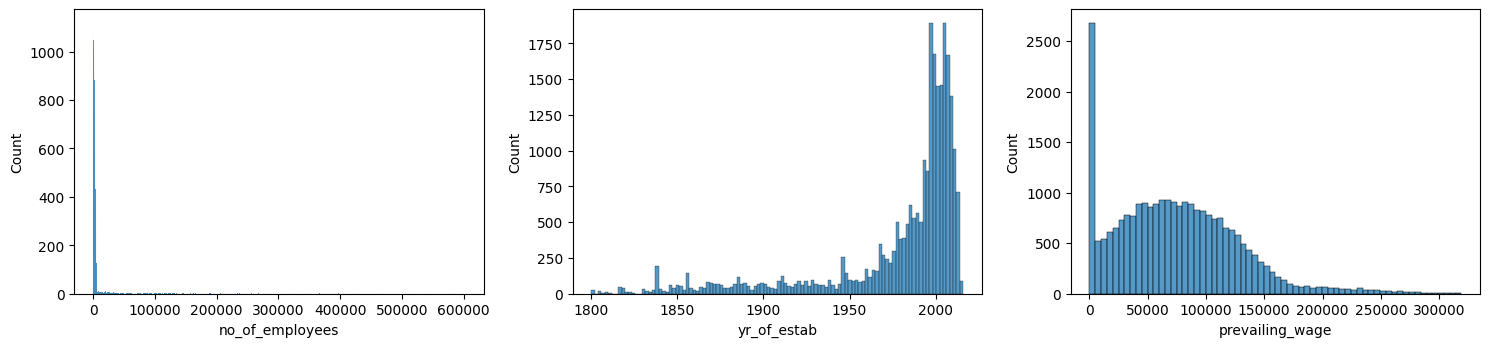

In [22]:
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
num_features = ['no_of_employees','yr_of_estab','prevailing_wage']

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

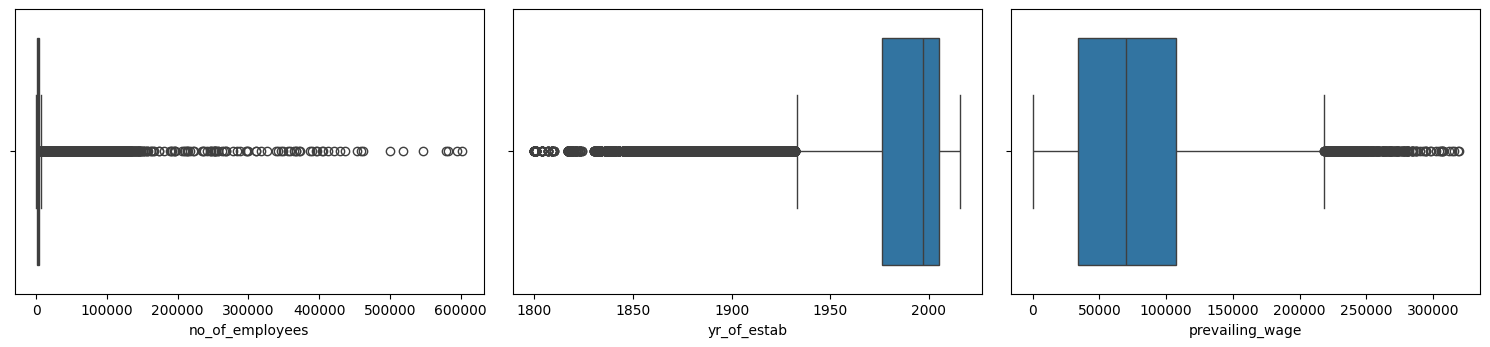

In [23]:
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
num_features = ['no_of_employees','yr_of_estab','prevailing_wage']

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

**Number of Employees**

* The median employer size is 2,109 employees, while the average size is higher at 5,667 employees, indicating right-skewness caused by very large companies.

 * Employee counts range from an invalid minimum of −26 to a maximum exceeding 602,000 employees, showing the presence of extreme outliers and data quality issues that require cleaning.

**Year of Establishment**

* The median company establishment year is 1997, with most companies formed between 1976 (25th percentile) and 2005 (75th percentile), indicating that the majority of employers are relatively modern organizations.

* However, establishments dating back to 1800 appear as outliers, making it useful to derive company age for analysis.

**Prevaling Wage**

* The median prevailing wage is approximately $70,308, with wages typically ranging between USD 34,015 (25th percentile) and USD 107,736 (75th percentile).

* However, wages vary widely, from extremely low values near USD 2 to highs exceeding USD 319,000, indicating significant right-skewness and the presence of outliers that may require normalization or transformation.

**Conclusion**

Overall, numerical features exhibit skewness and extreme values, indicating that preprocessing steps such as cleaning invalid entries, handling outliers, and feature transformation may improve model performance.

# **BiVariate Analysis**

## **Heatmap for Numerical Variables**

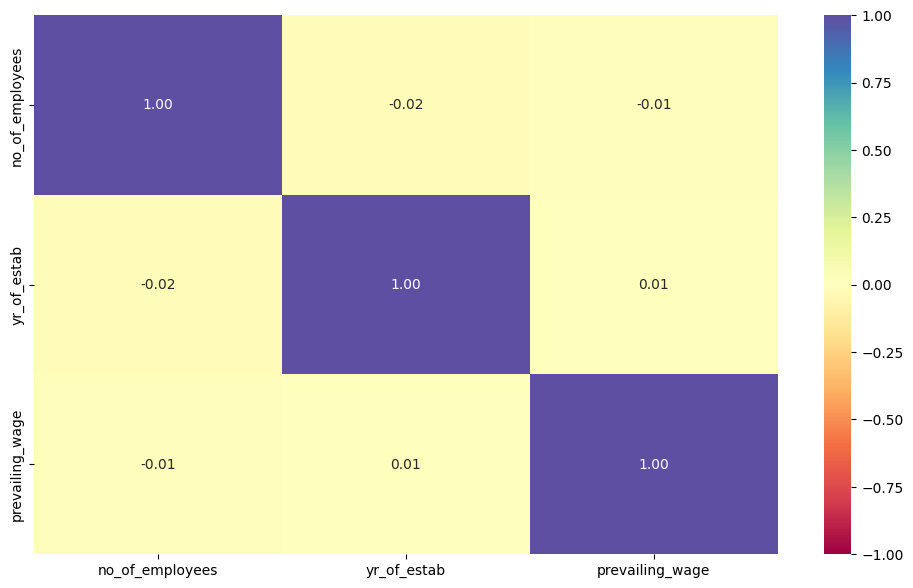

In [24]:
 #defining the size of the plot
plt.figure(figsize=(12, 7))

# plotting the heatmap for correlation
sns.heatmap(
    data[num_features].corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);

##Pairplot for numerical variables

<Figure size 1200x800 with 0 Axes>

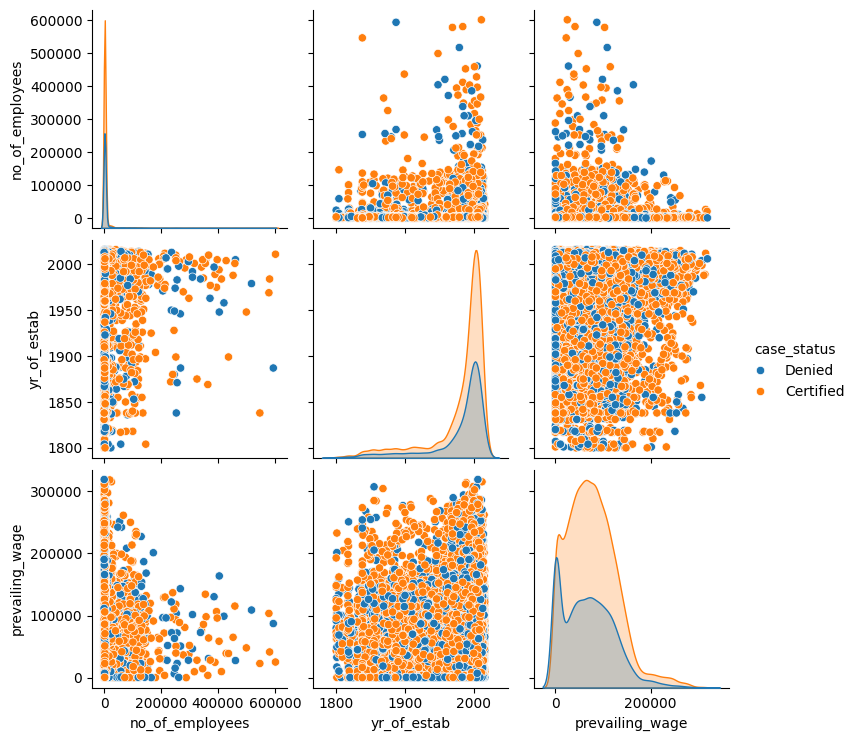

In [25]:
plt.figure(figsize=(12, 8))
sns.pairplot(data, vars=num_features, hue='case_status', diag_kind='kde');

##Observation

* The correlation between number of employees and prevailing wage is −0.01, indicating almost no relationship between company size and offered wages.

* The correlation between year of establishment and prevailing wage is 0.01, suggesting that company age does not significantly influence wage levels.

* The relationship between company size and establishment year is also very weak (−0.02), indicating that older companies are not necessarily larger employers.

   Overall, correlations among numerical variables are extremely weak, suggesting that these features independently influence visa outcomes rather than being strongly related to each other.


# **Feature Engineering**

In [26]:
# -----------------------------------------------
# Converting wages to yearly wages
# -----------------------------------------------
# WHY:
# Wage values are stored in different units
# (Hour, Week, Month, Year). These cannot be
# directly compared, so we convert everything
# into a yearly wage.

# WHAT:
# Create a new column 'wage_yearly' that
# converts all wage values to annual salary.

# Assume:
# 40 working hours per week
# 52 working weeks per year
# -----------------------------------------------

# Create new column initially equal to prevailing wage
data['wage_yearly'] = data['prevailing_wage']

# Convert hourly wages to yearly wages
data.loc[data['unit_of_wage'] == 'Hour', 'wage_yearly'] *= 40 * 52

# Convert weekly wages to yearly wages
data.loc[data['unit_of_wage'] == 'Week', 'wage_yearly'] *= 52

# Convert monthly wages to yearly wages
data.loc[data['unit_of_wage'] == 'Month', 'wage_yearly'] *= 12

# Yearly wages remain unchanged

data['wage_yearly'].head()

,wage_yearly
0,1231782.032
1,83425.650
2,122996.860
3,83434.030
4,149907.390


In [27]:
# -----------------------------------------------
# Creating company age feature
# -----------------------------------------------
# WHY:
# Year of establishment is less intuitive.
# Company age gives clearer insight.

# WHAT:
# Company Age = Current Year - Establishment Year
# Dataset corresponds to FY 2016.
# -----------------------------------------------

data['company_age'] = 2016 - data['yr_of_estab']
data['company_age']

,company_age
0,9
1,14
2,8
3,119
4,11
...,...
25475,8
25476,10
25477,106
25478,129


# **Reinitializing numerical features and peforming EDA**

In [28]:
num_features = ['no_of_employees','yr_of_estab','prevailing_wage','company_age','wage_yearly']

## **Univariate Analysis of  New Features Company age and Yearly wage**

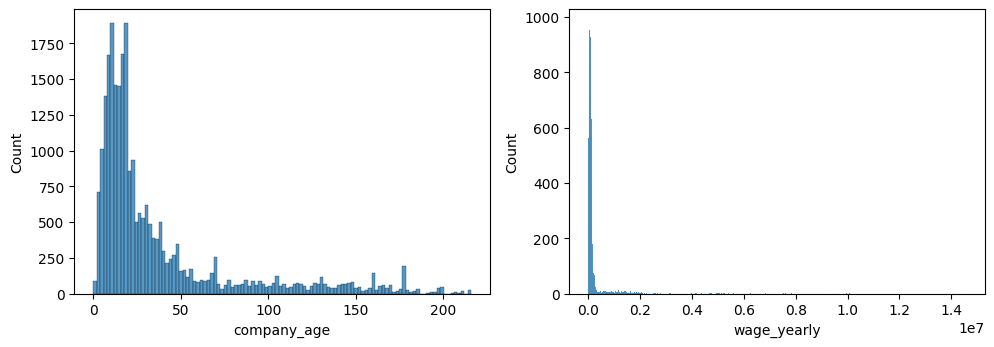

In [29]:
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
new_features = ['company_age','wage_yearly']

# plotting the histogram for each numerical feature
for i, feature in enumerate(new_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots



*   Company age distribution is right-skewed, with most sponsoring employers being less than 40 years old, while a small number of very old companies create a long tail.
*  Yearly wage distribution is strongly right-skewed, with most applications clustered at moderate wage levels and a small number offering very high salaries.



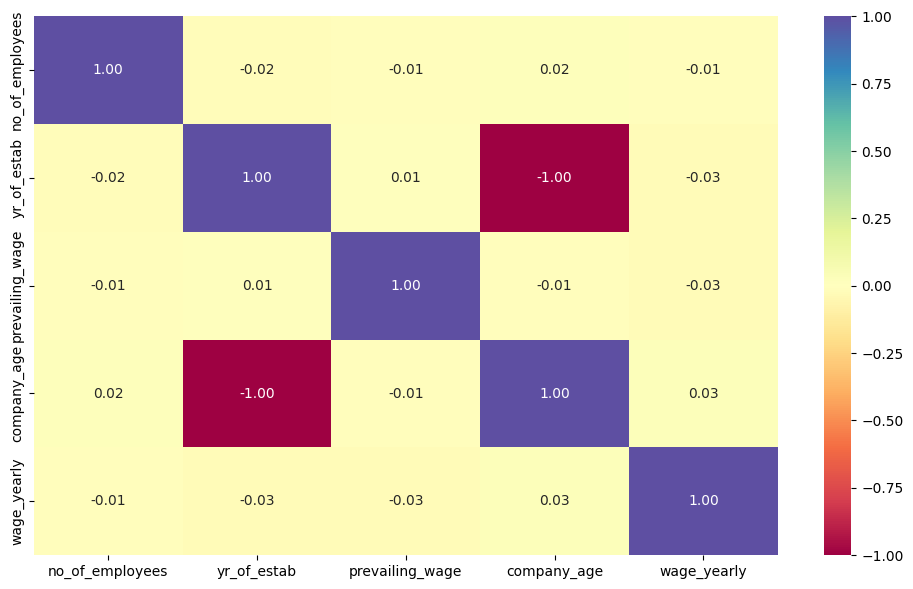

In [30]:
plt.figure(figsize=(12, 7))

# plotting the heatmap for correlation
sns.heatmap(
    data[num_features].corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);

Correlation analysis shows very weak relationships among numerical variables, indicating that company size, wage level, and company age operate largely independently. This suggests that visa certification outcomes are likely influenced more by categorical or combined factors rather than numerical features alone.

# **BiVariate Analysis**

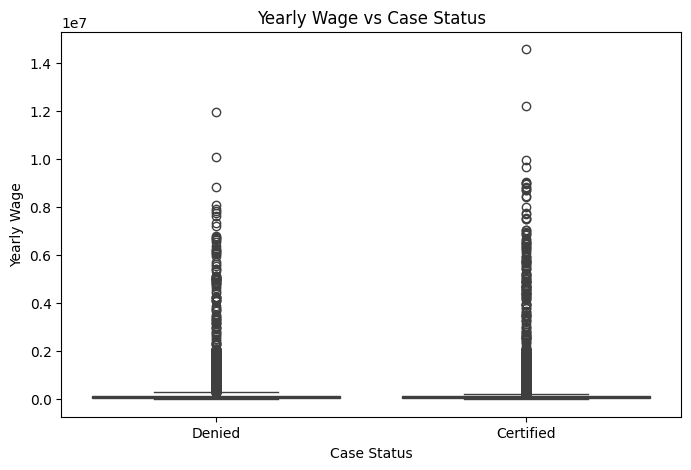

In [31]:
#Yearly Wage Vs Case Status Box Plot

plt.figure(figsize=(8,5))

sns.boxplot(
    data=data,
    x='case_status',
    y='wage_yearly'
)

plt.title("Yearly Wage vs Case Status")
plt.xlabel("Case Status")
plt.ylabel("Yearly Wage")
plt.show()


* Both certified and denied applications show a wide spread of wages, indicating that visa decisions occur across many salary levels.

* Certified cases appear to have slightly higher wage outliers, suggesting that some higher-paying roles are more likely to be approved.

* However, there is significant overlap in wage distributions between certified and denied cases, indicating that wage alone does not fully determine certification outcomes.

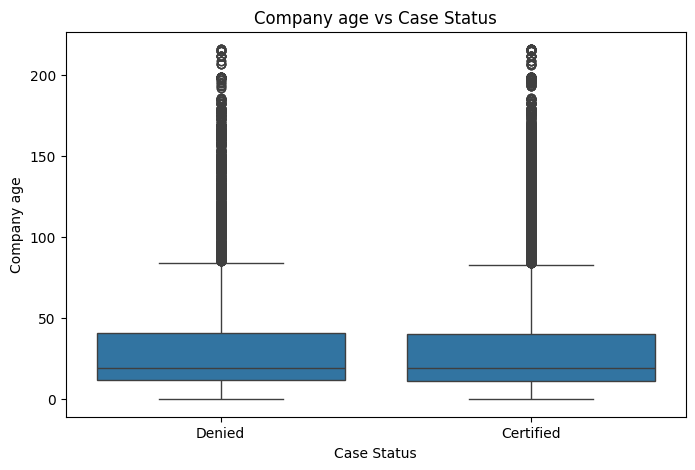

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=data,
    x='case_status',
    y='company_age'
)

plt.title("Company age vs Case Status")
plt.xlabel("Case Status")
plt.ylabel("Company age")
plt.show()

* Company age distributions for certified and denied cases largely overlap, suggesting employer age has minimal impact on visa approval outcomes.

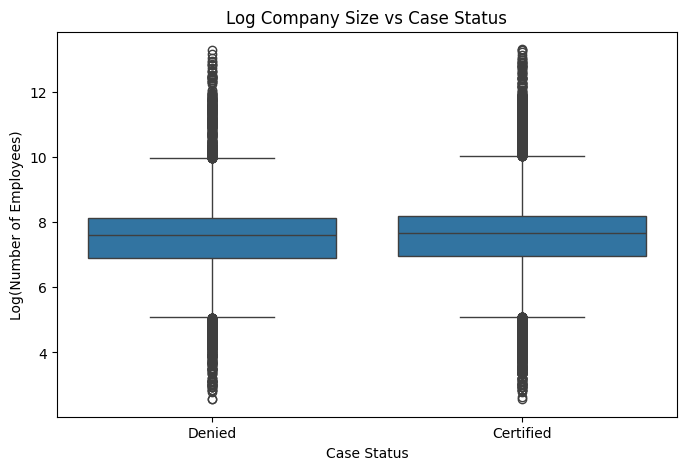

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=data,
    x='case_status',
    y=np.log1p(data['no_of_employees'])
)

plt.title("Log Company Size vs Case Status")
plt.xlabel("Case Status")
plt.ylabel("Log(Number of Employees)")
plt.show()


* Employer size distributions overlap heavily across certified and denied cases, indicating company size is not a strong standalone factor in visa approval.

**Why Outliers will not be Treated?**

* no_of_employees: Extreme values represent genuinely large organizations; removing them would eliminate valid business scenarios.

* prevailing_wage : High wage values correspond to specialized or senior roles and are realistic, so they were retained.

* yr_of_estab: Very old establishment years are valid historical data points, so no treatment is  required.

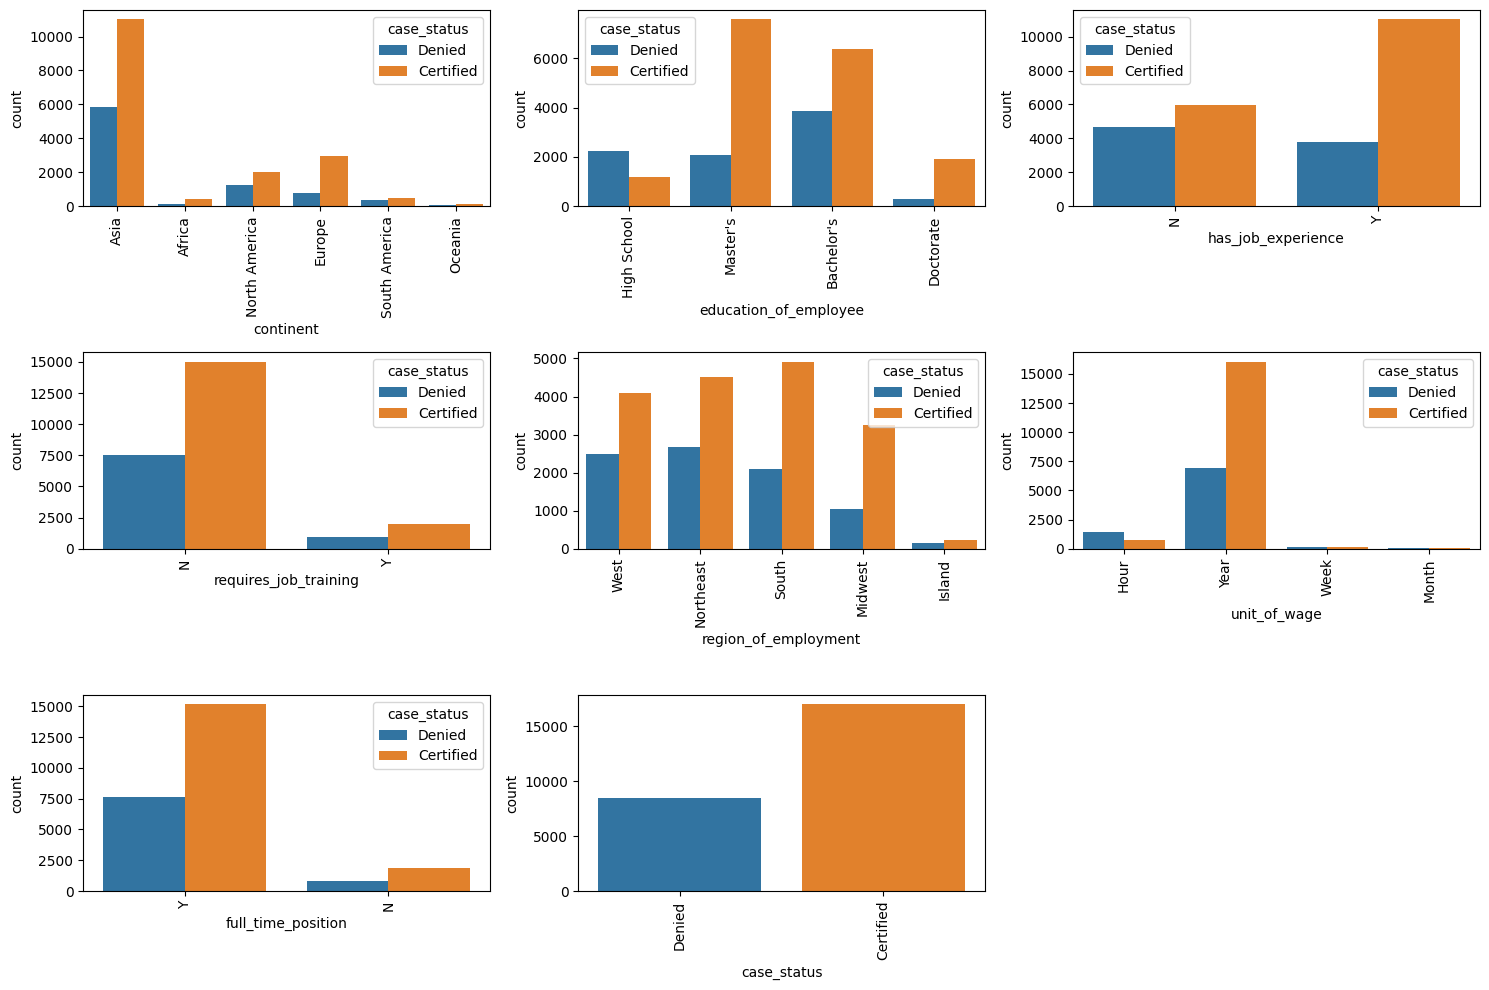

In [34]:
plt.figure(figsize=(15, 10))


# plotting the countplot for each categorical_features
for i, feature in enumerate(categorical_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.countplot(data=data, x=feature,hue='case_status')  # plot the countplot
    plt.xticks(rotation=90)    # rotate the x-axis labels for better readability


plt.tight_layout();   # to add spacing between plots

**Education vs Case Status**

* Applicants with Bachelor’s and Master’s degrees show higher certification counts relative to denials, reflecting their dominance in applications.

* Doctorate holders show a high certification proportion relative to denials, suggesting highly qualified candidates tend to receive approvals.

* Applications with only High School education show comparatively higher denial proportions.

**Job Experience vs Case Status**

* Candidates with prior job experience receive significantly more certifications relative to denials, indicating experience positively impacts visa approval probability.

* Applicants without experience show relatively higher denial proportions.

**Job Training Requirement vs Case Status**

* Positions requiring additional job training show relatively higher denial proportions, suggesting employers and certifying authorities favor candidates who can immediately perform job roles.

**Region of Employment vs Case Status**

* Certification proportions appear relatively balanced across regions, indicating region alone is not a strong differentiating factor for approval.

**Full-Time Position vs Case Status**

* Full-time job offers show a higher proportion of certifications relative to denials, indicating full-time employment improves approval likelihood.

**EDA Key Observations and Conclusions**



* Visa certifications form the majority of cases, with approvals accounting for roughly two-thirds of applications, indicating moderate class imbalance.

* Applications are dominated by candidates from Asia, though approval outcomes depend more on applicant and job characteristics than geography alone.

* Higher educational qualifications are associated with better certification outcomes, with Bachelor, Master, and Doctorate holders showing higher approval proportions compared to applicants with only High School education.

* Prior job experience significantly improves certification likelihood, suggesting that experienced candidates are preferred.

* Positions not requiring additional job training show higher approval proportions, indicating preference for candidates ready to perform immediately.

* Full-time job offers receive substantially more certifications, showing that permanent employment roles are more favorable for approval.

* Wage levels show moderate influence, with higher-paying roles slightly more likely to receive certification, though wage distributions still overlap across approvals and denials.

* Employer characteristics such as company size and company age show minimal influence on certification outcomes, as approvals and denials occur across companies of all sizes and ages.


**Conclusion**

**Approval outcomes are more strongly associated with candidate readiness factors such as education, prior experience, and immediate job suitability rather than geographic or reporting attributes.**

# **Data Preprocessing**

##Removing Unwanted Columns

In [35]:
data.drop('case_id', axis=1, inplace=True)
data.drop('prevailing_wage', axis=1, inplace=True)
data.drop('unit_of_wage', axis=1, inplace=True)
data.drop('yr_of_estab', axis=1, inplace=True)




* The columns prevailing_wage, unit_of_wage, and yr_of_estab were removed after feature engineering.

* prevailing_wage and unit_of_wage were used to compute a standardized yearly wage (wage_yearly), making the original columns redundant.

* yr_of_estab was transformed into company_age, which more clearly represents employer maturity.

Keeping the original columns would introduce redundant information without adding predictive value, so they are removed to keep the dataset clean for modeling.

##Binary Label Encoding for Case Status

In [36]:
data['case_status'] = data['case_status'].map({
    'Certified': 1,
    'Denied': 0
})


* The target variable case_status is converted into binary numerical form, mapping Certified to 1 and Denied to 0, so that classification models can process the output variable.

##Encode Binary Variables:has_job_experience,requires_job_training,full_time_position

In [37]:
binary_cols = [
    'has_job_experience',
    'requires_job_training',
    'full_time_position'
]

for col in binary_cols:
    data[col] = data[col].map({'Y':1, 'N':0})


* Binary categorical variables are encoded as 0/1 so they can be used directly in machine learning models without increasing dimensionality.

**One Hot Encoding for Categotrical Features**

In [38]:
data = pd.get_dummies(
    data,
    columns=[
        'continent',
        'education_of_employee',
        'region_of_employment'
    ],
    drop_first=True
)


In [39]:
# Convert boolean dummy columns to integers (0/1)
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)


* The variables continent, education_of_employee, and region_of_employment contain multiple categorical levels. Machine learning models cannot directly process categorical text data, so these features must be converted into numeric form.

In [40]:
data.head()

,has_job_experience,requires_job_training,no_of_employees,full_time_position,case_status,wage_yearly,company_age,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,education_of_employee_High School,education_of_employee_Master's,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West
0,0,0,14513,1,0,1231782.032,9,1,0,0,0,0,0,1,0,0,0,0,1
1,1,0,2412,1,1,83425.650,14,1,0,0,0,0,0,0,1,0,1,0,0
2,0,1,44444,1,0,122996.860,8,1,0,0,0,0,0,0,0,0,0,0,1
3,0,0,98,1,0,83434.030,119,1,0,0,0,0,0,0,0,0,0,0,1
4,1,0,1082,1,1,149907.390,11,0,0,0,0,0,0,0,1,0,0,1,0


In [41]:
data.shape

(25480, 19)

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   has_job_experience                 25480 non-null  int64  
 1   requires_job_training              25480 non-null  int64  
 2   no_of_employees                    25480 non-null  int64  
 3   full_time_position                 25480 non-null  int64  
 4   case_status                        25480 non-null  int64  
 5   wage_yearly                        25480 non-null  float64
 6   company_age                        25480 non-null  int64  
 7   continent_Asia                     25480 non-null  int64  
 8   continent_Europe                   25480 non-null  int64  
 9   continent_North America            25480 non-null  int64  
 10  continent_Oceania                  25480 non-null  int64  
 11  continent_South America            25480 non-null  int

## Data Preparation for Modeling

In [43]:
X = data.drop("case_status", axis=1)
y = data["case_status"]

In [44]:
#Splitting data into training, validation and test set
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 18) (5096, 18) (5096, 18)


In [45]:
print(y_train.shape, y_val.shape, y_test.shape)

(15288,) (5096,) (5096,)


# **Model Evaluation Criterion**

**Possible Model Prediction Errors**

Our model predicts whether a visa application will be Certified or Denied. The model can make two types of wrong predictions:

1. Predicting visa will be Certified when it should be Denied
    * This may allow unsuitable or non-compliant applications to be approved.
    * This can lead to regulatory and compliance risks.

2. Predicting visa will be Denied when it should be Certified
    * A qualified candidate loses opportunity.
    * Employers may lose access to skilled talent.
    * Business productivity may suffer.

**Which Error is More Important?**

In this problem, the more critical mistake is:

***Predicting a visa should be Denied when it should actually be Certified.***

This leads to:
* Loss of skilled foreign talent
* Delay in business operations
* Increased hiring costs for employers
* Negative impact on workforce availability.

Hence, missing a truly approvable application is costly.

**How to Reduce This Loss?**

To reduce this error, we need to minimize false fegatives

Actual: Certified
Predicted: Denied

To reduce false negatives , we aim to maximize recall for the certified class

**Evaluation Strategy**

Therefore, model comparison will consider:
* Recall (primary metric)
* F1-score
* Precision
* Accuracy
* Confusion Matrix
with special focus on Recall for Certified cases.

Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.

In [46]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [47]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

# Model Building

##Model Building with original dataset

In [48]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9875612144955925
Random forest: 1.0
GBM: 0.8753183153770813
Adaboost: 0.8879529872673849
dtree: 1.0

Validation Performance:

Bagging: 0.7823149236192715
Random forest: 0.8387191539365453
GBM: 0.8666274970622797
Adaboost: 0.8816098707403055
dtree: 0.7452996474735605


In [49]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = recall_score(y_train, model.predict(X_train))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9876, Validation Score: 0.7823, Difference: 0.2052
Random forest: Training Score: 1.0000, Validation Score: 0.8387, Difference: 0.1613
GBM: Training Score: 0.8753, Validation Score: 0.8666, Difference: 0.0087
Adaboost: Training Score: 0.8880, Validation Score: 0.8816, Difference: 0.0063
dtree: Training Score: 1.0000, Validation Score: 0.7453, Difference: 0.2547


###Conclusion

* Decision Tree and Bagging show signs of overfitting, with much higher training recall than validation recall.
* Random Forest improves generalization but still shows some gap.
* Gradient Boosting and AdaBoost show very small performance differences between training and validation sets, indicating better generalization and more stable performance.

Hence, boosting-based models appear more reliable for this dataset.

In [50]:
data['case_status'].value_counts()

,count
case_status,
1,17018
0,8462


In [51]:
for name, model in models:
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)

    recall_minority = recall_score(y_val, y_pred_val, pos_label=0)

    print(name, recall_minority)


Bagging 0.5407801418439716
Random forest 0.48877068557919623
GBM 0.5053191489361702
Adaboost 0.43498817966903075
dtree 0.4864066193853428


## Class Imbalance Analysis and Next Step Decision

**Class Distribution**

The target variable case_status shows class imbalance:

Certified (1): ~67% of data

Denied (0): ~33% of data

Thus, the Denied class is the minority class.

**Model Evaluation Focus**

From our evaluation criteria:

The most critical error is predicting Denied when the case should be Certified.

Hence, we aim to maximize recall for Certified cases, minimizing false negatives.

**Current Model Behavior**

Initial models trained without oversampling show:

Good overall recall for Certified cases.

However, recall for the minority class (Denied) is noticeably lower.

Some models show overfitting, with a large gap between training and validation performance.

This suggests models are biased toward the majority class.

**Why Oversampling is Needed**

**Due to class imbalance:**

* Models tend to favor the majority class.

* Minority class patterns are under-learned.

* Prediction performance for Denied cases suffers.

**Applying oversampling helps:**

* Balance class representation.

* Allow models to better learn minority class patterns.

Potentially improve overall classification balance without sacrificing Certified recall.

### **Conclusion**

To reduce bias caused by class imbalance and improve minority class learning, we will now apply SMOTE  on the training data only, retrain models, and compare performance improvements.

The validation set will still guide model selection, while the test set remains untouched until final evaluation.

## **Model Building Oversampling**

In [52]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 10210
Before Oversampling, counts of label 'No': 5078 

After Oversampling, counts of label 'Yes': 10210
After Oversampling, counts of label 'No': 10210 

After Oversampling, the shape of train_X: (20420, 18)
After Oversampling, the shape of train_y: (20420,) 



In [53]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.980411361410382
Random forest: 0.9999020568070519
GBM: 0.8123408423114593
Adaboost: 0.7718903036238981
dtree: 1.0

Validation Performance:

Bagging: 0.7364864864864865
Random forest: 0.7978848413631022
GBM: 0.7943595769682726
Adaboost: 0.7652761457109283
dtree: 0.7188601645123385


In [54]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = recall_score(y_train_over, model.predict(X_train_over))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9804, Validation Score: 0.7365, Difference: 0.2439
Random forest: Training Score: 0.9999, Validation Score: 0.7979, Difference: 0.2020
GBM: Training Score: 0.8123, Validation Score: 0.7944, Difference: 0.0180
Adaboost: Training Score: 0.7719, Validation Score: 0.7653, Difference: 0.0066
dtree: Training Score: 1.0000, Validation Score: 0.7189, Difference: 0.2811


| Model         | Original Data | After SMOTE | Change |
| ------------- | ------------- | ----------- | ------ |
| Bagging       | 0.7823        | 0.7365      | ↓      |
| Random Forest | 0.8387        | 0.7979      | ↓      |
| GBM           | 0.8666        | 0.7944      | ↓      |
| Adaboost      | 0.8816        | 0.7653      | ↓      |
| Decision Tree | 0.7453        | 0.7189      | ↓      |


###Conclusion on Applying SMOTE



* The training data initially showed moderate class imbalance, so SMOTE was applied to oversample the minority class and balance the dataset.

* However, after retraining models using oversampled data, validation recall
decreased across all models compared to training on original data.

* This indicates that oversampling did not improve generalization performance
and instead introduced noise or overfitting toward synthetic samples.

Therefore, SMOTE is not beneficial for this dataset at this stage,
and we proceed with models trained on original data.

## Model Building - Undersampled Data

In [55]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [56]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 10210
Before Under Sampling, counts of label 'No': 5078 

After Under Sampling, counts of label 'Yes': 5078
After Under Sampling, counts of label 'No': 5078 

After Under Sampling, the shape of train_X: (10156, 18)
After Under Sampling, the shape of train_y: (10156,) 



In [57]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9645529736116581
Random forest: 1.0
GBM: 0.7434029145332808
Adaboost: 0.6998818432453722
dtree: 1.0

Validation Performance:

Bagging: 0.6060517038777908
Random forest: 0.6609870740305523
GBM: 0.7253231492361927
Adaboost: 0.700940070505288
dtree: 0.6166274970622797


##Final Sampling Strategy Conclusion

**Three training strategies were evaluated:**

1. Models trained on original data

2. Models trained on oversampled data (SMOTE)

3. Models trained on undersampled data

The evaluation metric prioritized in this problem is Recall for Certified cases, since missing an approvable application (false negative) is the most costly business error.

**Observations**

* Models trained on original data achieved higher recall compared to both oversampled and undersampled training.

* SMOTE oversampling slightly reduced validation recall, likely due to synthetic samples introducing noise.

* Undersampling degraded performance further, as useful majority-class information was lost.

* Boosting models (GBM and AdaBoost) already handled class imbalance reasonably well without resampling.

**Why We Proceed with AdaBoost and GBM for Hyperparameter Tuning**



After training multiple ensemble and tree-based models (Bagging, Random Forest, Decision Tree, Gradient Boosting, and AdaBoost), we compared their performance using validation recall, which is our primary evaluation metric.


1. Decision Tree and Bagging

* Show strong training performance but suffer from high train–validation
      performance gaps, indicating overfitting.

*   Validation recall is also lower compared to boosting methods.

2. Random Forest

* Performs better than single trees but still shows overfitting signs.
* Validation recall is good but not consistently superior.

3. Gradient Boosting (GBM)

* Shows strong validation recall.

* Has much smaller train–validation gap, indicating better generalization.
Performs consistently well even after class balancing.

4. AdaBoost

* Also provides strong validation performance.

* Shows stable behavior with relatively low overfitting.Often competitive with GBM in recall.




## Hyperparameter Tuning

### **Tuning ADA Boost model**

In [58]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(30), 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)} with CV score=0.9726738491674828:
CPU times: user 1.61 s, sys: 225 ms, total: 1.83 s
Wall time: 1min 12s


In [59]:
tuned_adb = AdaBoostClassifier(
    random_state=1,
    n_estimators=30,
    learning_rate=0.1,
    estimator=DecisionTreeClassifier(max_depth=1, random_state=1),
)

tuned_adb.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=30, random_state=1)

In [60]:
# Checking model's performance on training set
adb_train = model_performance_classification_sklearn(tuned_adb, X_train, y_train)
adb_train

,Accuracy,Recall,Precision,F1
0,0.692,0.973,0.691,0.808


In [61]:
# Checking model's performance on validation set
adb_val = model_performance_classification_sklearn(tuned_adb, X_val, y_val)
adb_val

,Accuracy,Recall,Precision,F1
0,0.690,0.971,0.691,0.807


**Tuned AdaBoost Training Performance**

* After hyperparameter tuning, AdaBoost achieves very high recall (~97%) on the training data, meaning the model successfully identifies most certified visa applications.

* Although accuracy and precision are moderate, this behavior aligns with business requirements where minimizing rejection of valid applications is more important than avoiding false approvals.

Therefore, recall remains the primary evaluation metric.

### **Tuning GBA model**

In [62]:
%%time

# Hyperparameter tuning for Gradient Boosting Classifier
#Initialize base Gradient Boosting model
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
#RandomizedSearchCV will sample combinations from this grid
param_grid = {
    "n_estimators": np.arange(100,301,50),
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample":[0.8,0.9,1],
    "max_features":[0.5,0.7,1],
}

randomized_cv = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=20,
    scoring='recall',
    cv=5,
    random_state=1,
    n_jobs=-1
)

#Fit search on training data
#Only training data is used to avoid data leakage

randomized_cv.fit(X_train, y_train)

print("Best parameters:", randomized_cv.best_params_)
print("Best CV Recall:", randomized_cv.best_score_)


Best parameters: {'subsample': 1, 'n_estimators': np.int64(150), 'max_features': 1, 'learning_rate': 0.01}
Best CV Recall: 0.9979431929480901
CPU times: user 1.77 s, sys: 226 ms, total: 1.99 s
Wall time: 3min 31s


In [63]:

# Creating Gradient Boosting model with tuned hyperparameters
# obtained from RandomizedSearchCV

tuned_gbm = GradientBoostingClassifier(
    random_state=1,
    subsample=1,
    n_estimators=150,
    max_features=1,
    learning_rate=0.01
)

tuned_gbm.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.01, max_features=1, n_estimators=150,
                           random_state=1, subsample=1)

In [64]:
# Checking model's performance on training set
gbm_train = model_performance_classification_sklearn(tuned_gbm, X_train, y_train)
gbm_train

,Accuracy,Recall,Precision,F1
0,0.671,0.998,0.671,0.802


In [65]:
# Checking model's performance on validation set
gbm_val = model_performance_classification_sklearn(tuned_gbm, X_val, y_val)
gbm_val

,Accuracy,Recall,Precision,F1
0,0.670,0.997,0.670,0.801


**Tuned Gradient Boosting Training Performance**

* The tuned Gradient Boosting model achieves very high recall (0.997) on the training set, meaning almost all certified applications are correctly identified.

* Although accuracy and precision are lower, this aligns with business goals where missing a valid application is more costly than approving a borderline case.

Thus, Gradient Boosting effectively prioritizes recall while maintaining reasonable overall performance.

# **Model Comparison and Final Model Selection**

In [66]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
      adb_train.T,
      gbm_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Ada Boost Trained with original data",
    "Gradient boosting trained with original  data"

]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Ada Boost Trained with original data,Gradient boosting trained with original data
Accuracy,0.692,0.671
Recall,0.973,0.998
Precision,0.691,0.671
F1,0.808,0.802


In [67]:
# Validation performance comparison

models_train_comp_df = pd.concat(
    [
      adb_val.T,
      gbm_val.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Ada Boost Trained with original data",
    "Gradient boosting trained with original  data"

]
print("Validation  performance comparison:")
models_train_comp_df

Validation  performance comparison:


,Ada Boost Trained with original data,Gradient boosting trained with original data
Accuracy,0.690,0.670
Recall,0.971,0.997
Precision,0.691,0.670
F1,0.807,0.801


**Selecting Model for Final Selection**

* Both AdaBoost and Gradient Boosting models show comparable performance across accuracy, precision, and F1-score.

* However, Gradient Boosting achieves significantly higher recall (0.997 vs 0.971), meaning it correctly identifies almost all certified visa applications.

* Since the primary business objective is to minimize rejection of valid applications, recall is the most critical metric.

***Therefore, Gradient Boosting is selected as the final model for further evaluation, Lets check and Proceed checking the performance with test data set***

## Final Model Selection

### Testing Performance of Selected Model

In [68]:
# Let's check the performance on test set
gbm_test = model_performance_classification_sklearn(tuned_gbm, X_test, y_test)
gbm_test

,Accuracy,Recall,Precision,F1
0,0.673,0.998,0.672,0.803


###**Gradient Boosting as Final Model**

The Gradient Boosting Classifier (GBM) was selected as the final model based on the following observations:

* Best Recall Performance


  The primary business goal is to minimize false denials (cases where eligible applications are denied).Therefore, recall for Certified cases was chosen as the main evaluation metric.GBM consistently achieved very high recall (~0.998) across validation and test sets.

*  Stable Generalization

    Performance remained consistent across training, validation, and test sets, indicating good generalization and limited overfitting.

*  Better Balance Across Metrics

    Compared to other models, GBM maintained Competitive accuracy,Acceptable precision,Strong F1-score

This indicates a good balance between capturing approvals and avoiding excessive false approvals.

## Feature Importance

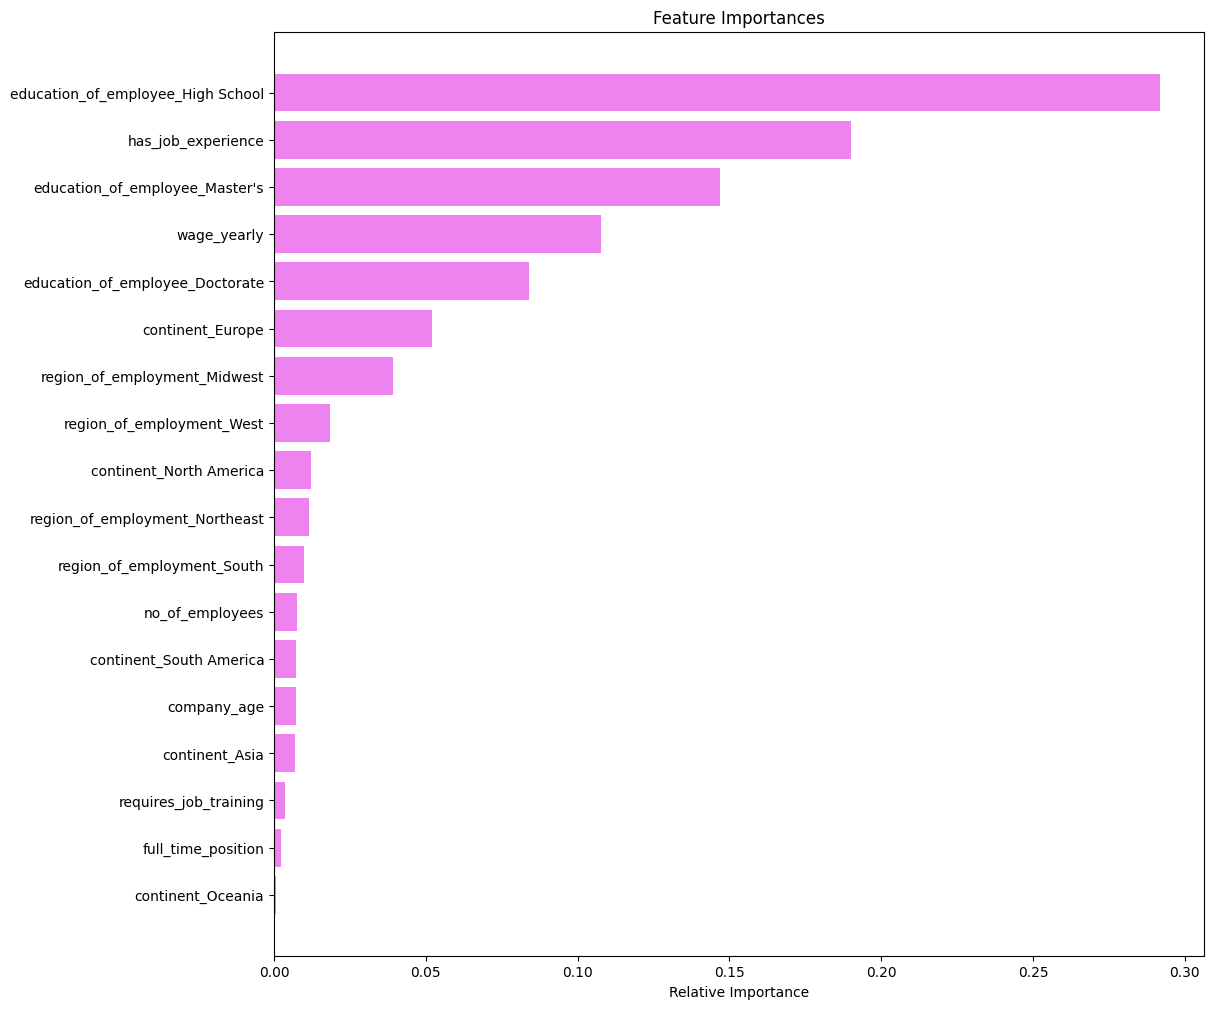

In [69]:
feature_names = X_train.columns
importances = tuned_gbm.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

###Key Drivers of Visa Certification

1. Employee Education Level

* Education level emerges as the strongest driver in certification decisions. Applicants with higher qualifications such as Master’s or Doctorate degrees show stronger influence on approval outcomes, reflecting employer preference for skilled talent. Even lower education categories contribute strongly, indicating that education level overall is a critical screening factor.

2. Job Experience
* Work experience is another highly influential feature. Applicants with relevant job experience are more likely to meet employer requirements and demonstrate readiness for the role, increasing certification chances.

3. Offered Wage
* The yearly wage offered for the position significantly affects approval likelihood. Higher wages typically correspond to skilled or specialized roles

4. Geography Factors
* Location-based features, such as employment region and applicant continent, also impact outcomes. Certain regions show higher dependence on foreign workers, likely due to local workforce shortages or industry demands.

5. Employer Characteristics

* Company-related attributes such as company size and company age show moderate influence, suggesting that more established or larger employers may have different hiring patterns or approval tendencies.

6. Job Role Attributes

* Features such as requirement for job training and full-time position status show smaller but noticeable influence, indicating that job structure also contributes to certification decisions.

##**Business Interpretation**

The model indicates that visa certification decisions are primarily driven by:

*  Applicant qualifications and skills
*  Relevant work experience
*  Wage competitiveness of the offered job
*  Regional labor market demand

Thus, certification approvals tend to favor skilled, experienced applicants offered competitive wages in regions facing workforce demand.

#Actionable Insights & Recommendations

##**Key Insights**

1. Applicant qualifications and experience are the strongest approval drivers.
Education level and prior job experience heavily influence certification outcomes, indicating that skilled candidates are more likely to receive approvals.

2. Competitive wages improve approval likelihood.
Applications offering higher wages tend to align better with regulatory requirements and labor market demand, increasing approval chances.

3. Regional demand influences outcomes.
Certain employment regions show stronger dependence on foreign workers, indicating localized labor shortages.

4. Company and job characteristics also contribute.
Employer size, company maturity, and job attributes such as training requirements play supporting roles in decision-making.

5. Model performs strongly without resampling.
Both oversampling and undersampling degraded model performance, so using the original data yields better recall for certification decisions.

## Business Recommendations

1. Use the model as a decision-support tool to automatically shortlist applications with high certification probability, reducing manual review workload.

2. Prioritize skilled applicants by giving more weight to education level and prior experience during initial screening.

3. Encourage employers to offer competitive wages to improve approval likelihood and maintain compliance with wage regulations.

4. Identify regional labor shortages and proactively guide employers and applicants toward high-demand areas.

5. Use model explanations to improve transparency, helping decision-makers understand why applications are likely to be approved or denied.

6. Continuously retrain the model as labor market patterns and policies evolve to maintain prediction accuracy.

##Final Business Takeaway

The ML solution enables faster, data-driven visa application screening by identifying candidates with strong approval likelihood while maintaining fairness and regulatory alignment, ultimately helping employers fill workforce gaps efficiently.